In [1]:
import numpy
from scipy.sparse import diags

In [2]:
import sys
import os

ROOT = os.path.abspath("..")
sys.path.append(ROOT)

from src.oracles import *
from src.optimization import *
from plot_trajectory_2d import *

In [3]:
def gen_func(n: int, k: float) -> QuadraticOracle:
    if n == 1:
        raise RuntimeError('n at least 2')
    eigen_values = np.array([1, k])
    if n > 2:
        eigen_values = np.concatenate((eigen_values, np.random.uniform(1, k, size=n-2)))
    A = diags(eigen_values)
    b = np.random.normal(0, 1, size=n)
    return QuadraticOracle(A, b)


def test_several_times(n: int, k_low: float, k_high: float, test_amount: int, max_iter=10000) -> list[(int, float)]:
    k_s = np.logspace(k_low, k_high, test_amount)
    results = []
    for k in k_s:
        oracle = gen_func(n, k)
        x_0, result, history = gradient_descent(
            oracle, np.zeros(n), trace=True, tolerance=1e-10, max_iter=max_iter)
            # line_search_options={'method': 'Constant', 'c': 1e-3})
        results.append((len(history['func']) - 1, k))
    return results

In [4]:
repeat_amount = 5
min_k = 0
max_k = 5

In [5]:
global_test_cases = [
    ('green', 10**1),
    ('red', 10**2),
    ('blue', 10**3),
    ('purple', 10**4),
    ('orange', 10**5),
]

In [6]:
data = []

In [7]:
for color, n in global_test_cases:
    data.append([])
    for i in range(repeat_amount):
        data[-1].append(test_several_times(n, min_k, max_k, min_k + max_k + 1, max_iter=5000))
        print(f'{n}, {i}')

10, 0
10, 1
10, 2
10, 3
10, 4
100, 0
100, 1
100, 2
100, 3
100, 4
1000, 0
1000, 1
1000, 2
1000, 3
1000, 4
10000, 0
10000, 1
10000, 2
10000, 3
10000, 4
100000, 0
100000, 1
100000, 2
100000, 3
100000, 4


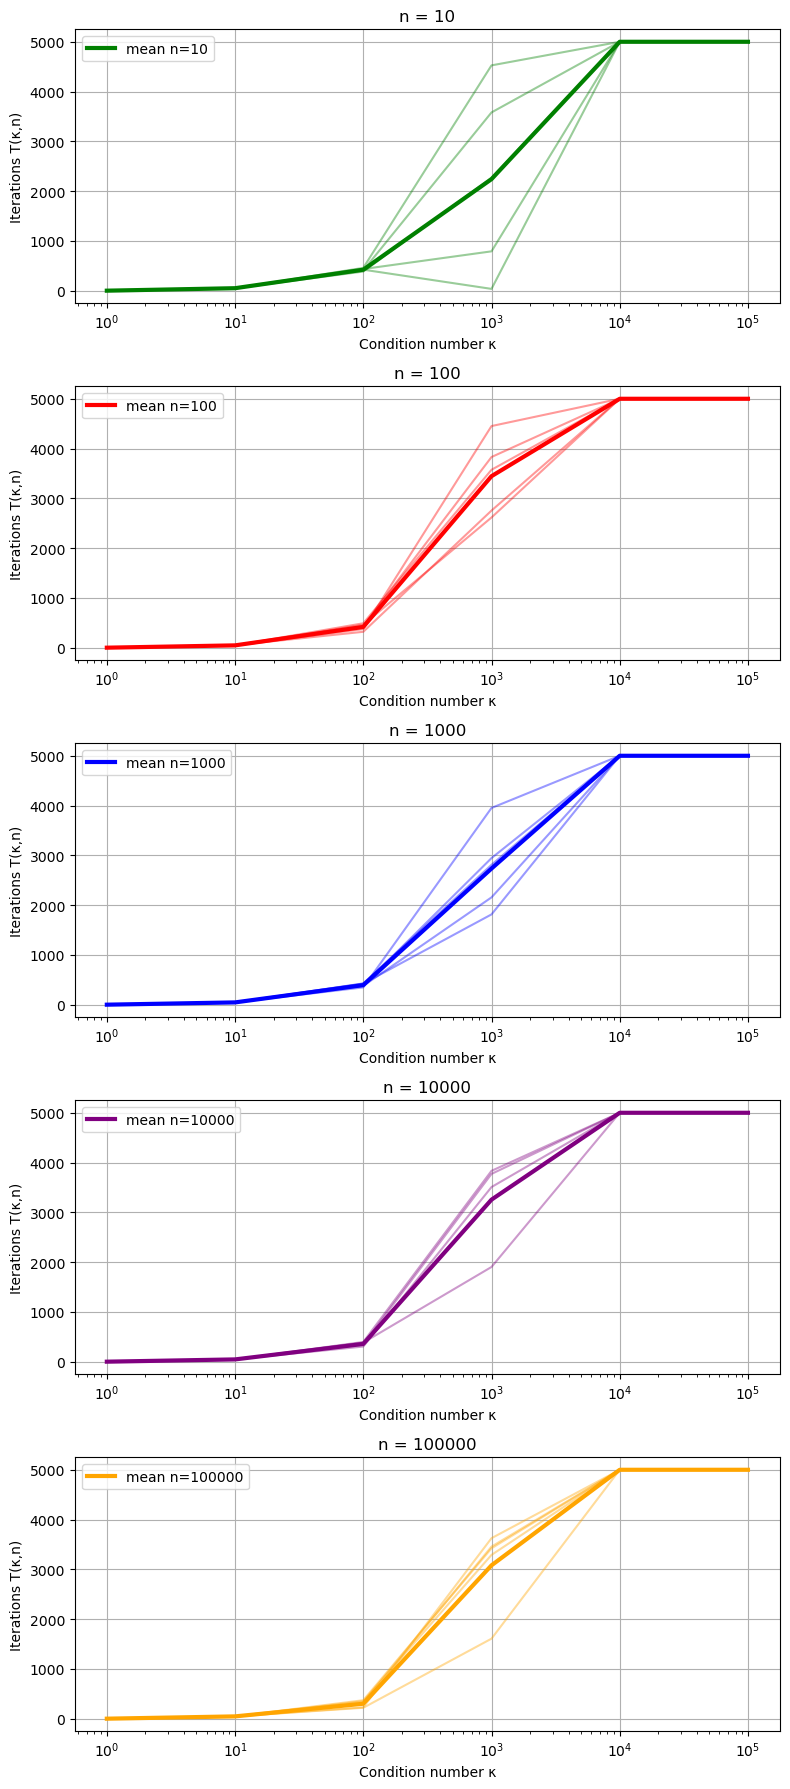

In [8]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(len(global_test_cases), 1, figsize=(8, 18))

for ax, ((color, n), runs) in zip(axes, zip(global_test_cases, data)):

    all_iters = []

    for run in runs:
        ks = [k for t, k in run]
        iters = [t for t, k in run]

        all_iters.append(iters)

        ax.semilogx(ks, iters, color=color, alpha=0.4)

    mean_iters = np.mean(all_iters, axis=0)
    ax.semilogx(ks, mean_iters, color=color, linewidth=3, label=f"mean n={n}")

    ax.set_title(f"n = {n}")
    ax.set_xlabel("Condition number κ")
    ax.set_ylabel("Iterations T(κ,n)")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()

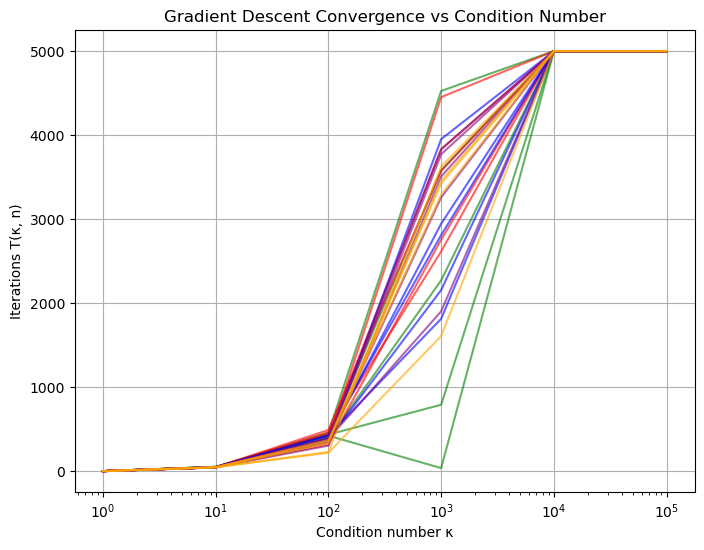

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for (color, n), runs in zip(global_test_cases, data):

    for run in runs:
        ks = [k for _, k in run]
        iters = [t for t, _ in run]

        plt.semilogx(ks, iters, color=color, alpha=0.6)

plt.xlabel("Condition number κ")
plt.ylabel("Iterations T(κ, n)")
plt.title("Gradient Descent Convergence vs Condition Number")

plt.grid(True)
plt.show()

In [10]:
print(data)

[[[(1, np.float64(1.0)), (52, np.float64(10.0)), (423, np.float64(100.0)), (37, np.float64(1000.0)), (5000, np.float64(10000.0)), (5000, np.float64(100000.0))], [(1, np.float64(1.0)), (51, np.float64(10.0)), (436, np.float64(100.0)), (791, np.float64(1000.0)), (5000, np.float64(10000.0)), (5000, np.float64(100000.0))], [(1, np.float64(1.0)), (51, np.float64(10.0)), (459, np.float64(100.0)), (4526, np.float64(1000.0)), (5000, np.float64(10000.0)), (5000, np.float64(100000.0))], [(1, np.float64(1.0)), (52, np.float64(10.0)), (408, np.float64(100.0)), (3581, np.float64(1000.0)), (5000, np.float64(10000.0)), (5000, np.float64(100000.0))], [(1, np.float64(1.0)), (48, np.float64(10.0)), (385, np.float64(100.0)), (2271, np.float64(1000.0)), (5000, np.float64(10000.0)), (5000, np.float64(100000.0))]], [[(1, np.float64(1.0)), (47, np.float64(10.0)), (461, np.float64(100.0)), (2616, np.float64(1000.0)), (5000, np.float64(10000.0)), (5000, np.float64(100000.0))], [(1, np.float64(1.0)), (49, np.fl